<a href="https://colab.research.google.com/github/bhargavikapuri03-source/Responsible-AI-Model-Interpretation/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
pip install shap lime scikit-learn pandas matplotlib seaborn

In [9]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

load dataset

In [10]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("customer_churn_data.csv")

Saving customer_churn_data.csv to customer_churn_data (1).csv


preprocess data

In [11]:
df.drop("customerID", axis=1, inplace=True)

df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

df = pd.get_dummies(df)

train model

In [12]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

Accuracy: 0.4931972789115646


feature importance

                           Feature  Importance
2                   MonthlyCharges    0.148253
3                     TotalCharges    0.147770
1                           tenure    0.132669
0                    SeniorCitizen    0.030747
8                    Dependents_No    0.020807
38               Contract_Two year    0.020743
37               Contract_One year    0.020697
43  PaymentMethod_Electronic check    0.020419
44      PaymentMethod_Mailed check    0.020275
9                   Dependents_Yes    0.020177


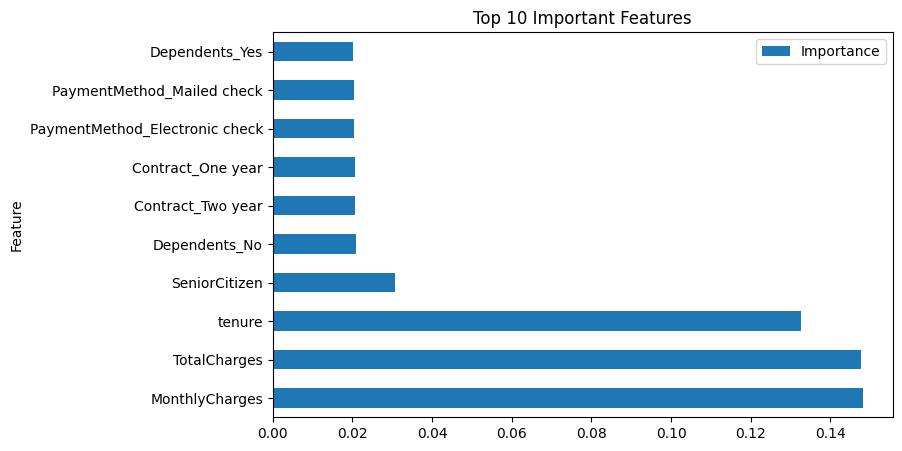

In [13]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))
importance.head(10).plot(
    kind="barh",
    x="Feature",
    y="Importance",
    figsize=(8,5)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

SHAP Explanation

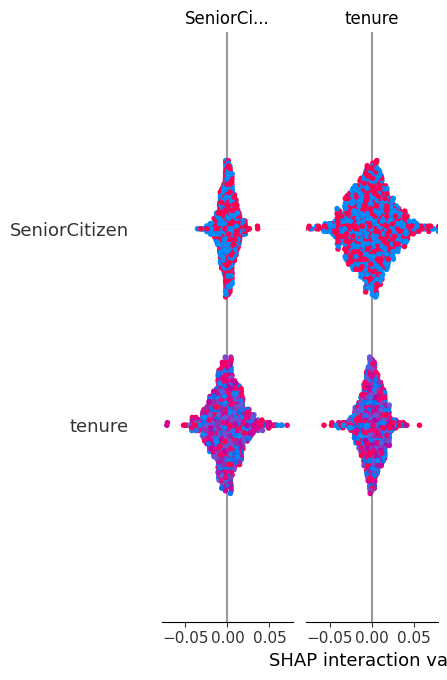

In [17]:
import shap

shap.initjs()
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)
shap.summary_plot(
    shap_values,
    X_test
)
shap.force_plot(
    explainer.expected_value[1],
    shap_values[0, :, 1],
    X_test.iloc[0]
)